<img src="https://upload.wikimedia.org/wikipedia/commons/8/89/TheNorthFace_logo.svg" alt="THE NORTH FACE LOGO" width="20%"/>

# The North Face e-commerce : boosting online sales !

In [1]:
#Charger toutes les librairies nécessaires
import pandas as pd
import en_core_web_sm
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
import numpy as np
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import wordcloud


In [2]:
df = pd.read_csv('sample-data.csv')
df.head()

,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


In [3]:
df[df['description'].str.contains('sonar', case=False)].to_csv("sonar.csv")

In [4]:
#Nombre de produits
print(f"Nombre de produits dans le Catalogue : {df.shape[0]}")

Nombre de produits dans le Catalogue : 500


In [5]:
#suppression des caractères qui ne sont pas alphanumériques, mettre en bas de casse

df['desc_clean'] = df['description'].str.replace(r"[^A-Za-z0-9]+", " ")
df['desc_clean'] = df['desc_clean'].fillna('').apply(lambda x: x.lower())
df['desc_clean'] = df['desc_clean'].\
    apply(lambda x : 
    x.replace("<li>",'')\
    .replace("</li>",'')\
    .replace("<br>",'')\
    .replace("</br>",'')\
    .replace("<b>",'')\
    .replace("</b>",'')\
    .replace("<ul>",'')\
    .replace("</ul>",'')\
    .replace(" . ", " ")
    .replace(" .", " ")  
    .replace('"', " ")
    .replace('  ', " ")
    .replace(" . ", " ")
    .replace(" - ", " ")\
    .replace(" %", "%")\
    .replace(" g", "g"))


In [6]:
df.head()

,id,description,desc_clean
0,1,Active classic boxers - There's a reason why o...,active classic boxers there's a reason why our...
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning upglory req...
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no-f...
3,4,"Alpine guide pants - Skin in, climb ice, switc...","alpineguide pants skin in, climb ice, switch t..."
4,5,"Alpine wind jkt - On high ridges, steep ice an...","alpine wind jkt on high ridges, steep ice and ..."


In [7]:
df["desc_clean"][0]

"active classic boxers there's a reason why our boxers are a cult favorite they keep their cool, especially in sticky situations. the quick-drying, lightweight underwear takes up minimal space in a travel pack. an exposed, brushed waistband offers next-to-skin softness, five-panel construction with a traditional boxer back for a classic fit, and a functional fly. made of 3.7-oz 100% recycled polyester with moisture-wicking performance. inseam (size m) is 4 1/2 recyclable through the common threads recycling program.details: silky capilene 1 fabric is ultralight, breathable and quick-to-dry  exposed, brushed elastic waistband for comfort 5-panel construction with traditional boxer back inseam (size m) is 4 1/2  fabric: 3.7-oz 100% all-recycled polyester withgladiodor natural odor control for thegarment. recyclable through the common threads recycling programweight: 99g (3.5 oz)made in mexico."

In [8]:
# Import librairie Anglais en_core_web_sm.load()

nlp = en_core_web_sm.load()

In [9]:
#Lemmatization et on retire les Stop Words
df["desc_tokenized"] = df["desc_clean"]\
    .fillna('')\
    .apply(lambda x: [token.lemma_ for token in nlp(x) if token.text not in STOP_WORDS])
df.head()

,id,description,desc_clean,desc_tokenized
0,1,Active classic boxers - There's a reason why o...,active classic boxers there's a reason why our...,"[active, classic, boxer, reason, boxer, cult, ..."
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning upglory req...,"[active, sport, boxer, brief, skin, upglory, r..."
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no-f...,"[active, sport, brief, superbreathable, -, fly..."
3,4,"Alpine guide pants - Skin in, climb ice, switc...","alpineguide pants skin in, climb ice, switch t...","[alpineguide, pant, skin, ,, climb, ice, ,, sw..."
4,5,"Alpine wind jkt - On high ridges, steep ice an...","alpine wind jkt on high ridges, steep ice and ...","[alpine, wind, jkt, high, ridge, ,, steep, ice..."


In [10]:
#Rassemblement des mots
df["desc_ready"] = df["desc_tokenized"].apply(lambda x: (" ".join(x)).strip())

df

,id,description,desc_clean,desc_tokenized,desc_ready
0,1,Active classic boxers - There's a reason why o...,active classic boxers there's a reason why our...,"[active, classic, boxer, reason, boxer, cult, ...",active classic boxer reason boxer cult favorit...
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning upglory req...,"[active, sport, boxer, brief, skin, upglory, r...",active sport boxer brief skin upglory require ...
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no-f...,"[active, sport, brief, superbreathable, -, fly...",active sport brief superbreathable - fly brief...
3,4,"Alpine guide pants - Skin in, climb ice, switc...","alpineguide pants skin in, climb ice, switch t...","[alpineguide, pant, skin, ,, climb, ice, ,, sw...","alpineguide pant skin , climb ice , switch roc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an...","alpine wind jkt on high ridges, steep ice and ...","[alpine, wind, jkt, high, ridge, ,, steep, ice...","alpine wind jkt high ridge , steep ice alpine ..."
...,...,...,...,...,...
495,496,Cap 2 bottoms - Cut loose from the maddening c...,cap 2 bottoms cut loose from the maddening cro...,"[cap, 2, bottom, cut, loose, madden, crowd, se...",cap 2 bottom cut loose madden crowd search und...
496,497,Cap 2 crew - This crew takes the edge off fick...,cap 2 crew this crew takes the edge off fickle...,"[cap, 2, crew, crew, take, edge, fickle, weath...",cap 2 crew crew take edge fickle weather . cle...
497,498,All-time shell - No need to use that morning T...,all-time shell no need to use that morning tim...,"[-, time, shell, need, use, morning, time, umb...",- time shell need use morning time umbrella . ...
498,499,All-wear cargo shorts - All-Wear Cargo Shorts ...,all-wear cargo shorts all-wear cargo shorts ba...,"[-, wear, cargo, short, -, wear, cargo, short,...",- wear cargo short - wear cargo short bask the...


In [11]:
df['desc_ready'][0]

'active classic boxer reason boxer cult favorite cool , especially sticky situation . quick - dry , lightweight underwear take minimal space travel pack . expose , brush waistband offer - - skin softness , - panel construction traditional boxer classic fit , functional fly . 3.7 - oz 100 % recycled polyester moisture - wicke performance . inseam ( size m ) 4 1/2 recyclable common thread recycle program.detail : silky capilene 1 fabric ultralight , breathable quick - - dry   expose , brush elastic waistband comfort 5 - panel construction traditional boxer inseam ( size m ) 4 1/2   fabric : 3.7 - oz 100 % - recycle polyester withgladiodor natural odor control thegarment . recyclable common thread recycle programweight : 99 g ( 3.5 oz)made mexico .'

In [12]:
df['desc_ready'][255]

'solimar skirt solimar brief sassy wrap skirt build - short ; skirt school , short recess . ultralight , tightly weave nylon stretch fabric block uv ray ( 30 upf ) dwr ( durable water repellent ) finish repel water . short interior center - zip skirt wrap button closure inside outside . cleanly finished skirt welt patch pocket thigh mini drop - pocket . waist - - hem length 16 ( size 8) ; build - short inseam 3 recyclable common thread recycle program.detail : lightweight stretch fabric 30 - upf sun protection dwr ( durable water repellent ) finish wrap skirt build - short short zip fly slide closure ; skirt wrap close 2 button patch pocket welt opening ; mini drop - pocket right thigh dart shape length 16   waist hem ; short 3   inseam fabric : 3 - oz 93 % nylon/7 % spandex 30 - upf sun protection . recyclable common thread recycle programweight : ( 222 g 7.7 oz)made vietnam .'

In [13]:
#nettoyage supplémentaire

df["desc_ready"] = df["desc_ready"].apply(lambda x: 
                    x.replace(" , ", " ")
                    .replace(" . ", " ")
                    .replace(" .", " ")  
                    .replace('"', " ")
                    .replace('" "', " ")
                    .replace(" . ", " ")
                    .replace(" %", "%")
                    .replace(" g", "g")
                    .replace(" oz", "oz")
                    .replace("-oz", "oz")
                    .replace(" (", " ")
                    .replace(")", " ")
                    .replace('/', " ")
                    .replace(' - ', " ")
                    .replace(' : ', " ")
                    .replace(' ; ', " ")
                    .replace('- ', " ")
                    .replace(' ?', " ")
                    .replace('  ', " ")
                    .replace('   ', " ")
                    )
df["desc_ready"] = df["desc_ready"].apply(lambda x: x.strip())

df

,id,description,desc_clean,desc_tokenized,desc_ready
0,1,Active classic boxers - There's a reason why o...,active classic boxers there's a reason why our...,"[active, classic, boxer, reason, boxer, cult, ...",active classic boxer reason boxer cult favorit...
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning upglory req...,"[active, sport, boxer, brief, skin, upglory, r...",active sport boxer brief skin upglory require ...
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no-f...,"[active, sport, brief, superbreathable, -, fly...",active sport brief superbreathable fly brief m...
3,4,"Alpine guide pants - Skin in, climb ice, switc...","alpineguide pants skin in, climb ice, switch t...","[alpineguide, pant, skin, ,, climb, ice, ,, sw...",alpineguide pant skin climb ice switch rock tr...
4,5,"Alpine wind jkt - On high ridges, steep ice an...","alpine wind jkt on high ridges, steep ice and ...","[alpine, wind, jkt, high, ridge, ,, steep, ice...",alpine wind jkt high ridge steep ice alpine ja...
...,...,...,...,...,...
495,496,Cap 2 bottoms - Cut loose from the maddening c...,cap 2 bottoms cut loose from the maddening cro...,"[cap, 2, bottom, cut, loose, madden, crowd, se...",cap 2 bottom cut loose madden crowd search und...
496,497,Cap 2 crew - This crew takes the edge off fick...,cap 2 crew this crew takes the edge off fickle...,"[cap, 2, crew, crew, take, edge, fickle, weath...",cap 2 crew crew take edge fickle weather clear...
497,498,All-time shell - No need to use that morning T...,all-time shell no need to use that morning tim...,"[-, time, shell, need, use, morning, time, umb...",time shell need use morning time umbrella time...
498,499,All-wear cargo shorts - All-Wear Cargo Shorts ...,all-wear cargo shorts all-wear cargo shorts ba...,"[-, wear, cargo, short, -, wear, cargo, short,...",wear cargo short wear cargo short bask theglor...


In [14]:
df['desc_ready'][0] 

'active classic boxer reason boxer cult favorite cool especially sticky situation quick dry lightweight underwear take minimal space travel pack expose brush waistband offer skin softness panel construction traditional boxer classic fit functional fly 3.7 oz 100% recycled polyester moisture wicke performance inseam size m  4 1 2 recyclable common thread recycle program.detail silky capilene 1 fabric ultralight breathable quick dry  expose brush elastic waistband comfort 5 panel construction traditional boxer inseam size m  4 1 2  fabric 3.7 oz 100% recycle polyester withgladiodor natural odor control thegarment recyclable common thread recycle programweight 99g 3.5oz made mexico'

In [15]:
df['desc_ready'][255]

'solimar skirt solimar brief sassy wrap skirt build short skirt school short recess ultralight tightly weave nylon stretch fabric block uv ray 30 upf  dwr durable water repellent  finish repel water short interior center zip skirt wrap button closure inside outside cleanly finished skirt welt patch pocket thigh mini drop pocket waist hem length 16 size 8 build short inseam 3 recyclable common thread recycle program.detail lightweight stretch fabric 30 upf sun protection dwr durable water repellent  finish wrap skirt build short short zip fly slide closure skirt wrap close 2 button patch pocket welt opening mini drop pocket right thigh dart shape length 16  waist hem short 3  inseam fabric 3 oz 93% nylon 7% spandex 30 upf sun protection recyclable common thread recycle programweight 222g 7.7oz made vietnam'

In [16]:
# Tfidf transformer / It takes a collection of text data and converts it into a matrix of token counts.
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', smooth_idf=True)
X = vectorizer.fit_transform(df['desc_ready'])

In [17]:
dense = X.toarray()
dense

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(500, 4276))

In [18]:
vectorizer.vocabulary_

{'active': 386,
 'classic': 944,
 'boxer': 745,
 'reason': 2955,
 'cult': 1179,
 'favorite': 1571,
 'cool': 1094,
 'especially': 1494,
 'sticky': 3542,
 'situation': 3351,
 'quick': 2910,
 'dry': 1376,
 'lightweight': 2192,
 'underwear': 3982,
 'minimal': 2387,
 'space': 3462,
 'travel': 3894,
 'pack': 2635,
 'expose': 1526,
 'brush': 778,
 'waistband': 4107,
 'offer': 2547,
 'skin': 3364,
 'softness': 3440,
 'panel': 2658,
 'construction': 1071,
 'traditional': 3877,
 'fit': 1624,
 'functional': 1751,
 'fly': 1673,
 'oz': 2632,
 '100': 5,
 'recycled': 2965,
 'polyester': 2797,
 'moisture': 2413,
 'wicke': 4190,
 'performance': 2715,
 'inseam': 1999,
 'size': 3352,
 'recyclable': 2963,
 'common': 1026,
 'thread': 3805,
 'recycle': 2964,
 'program': 2858,
 'silky': 3328,
 'capilene': 843,
 'fabric': 1545,
 'ultralight': 3961,
 'breathable': 755,
 'elastic': 1426,
 'comfort': 1015,
 'withgladiodor': 4213,
 'natural': 2467,
 'odor': 2546,
 'control': 1085,
 'thegarment': 3766,
 'programwe

In [19]:
len(vectorizer.vocabulary_)

4276

## Création de Clusters sous DBSCAN

In [27]:
# import DBSCAN from sklearn and numpy
from sklearn.cluster import DBSCAN
import numpy as np

#dbscan = DBSCAN(eps=0.7, min_samples=3, metric="cosine")
dbscan = DBSCAN(eps=0.7, min_samples=2, metric="cosine")
dbscan.fit(X)
clusters = np.unique(dbscan.labels_)
print(f"DBSCAN a créé {len(clusters)} Clusters : {len(clusters)}")

DBSCAN a créé 26 Clusters : 26


In [21]:
clusters

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24])

## Recherche du nombre idéal de clusters par rapport aux outliers

In [22]:
esp_val = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7] #eps le rayon autour d'un point dans lequel on recherche des voisins pour former un cluster.
min_sam_val = [2, 3, 4, 5, 6, 7, 8, 9, 10] #nombre minimum de points requis dans le voisinage d'un point pour qu'il soit considéré comme un point central d'un cluster
 
for i in esp_val:
    for j in min_sam_val:
        dbscan = DBSCAN(eps=i, min_samples=j, metric="cosine")
        dbscan.fit(X)
        n_noise = np.sum(dbscan.labels_ == -1)
        el_clusters = len(dbscan.labels_)
        total_clusters = len(np.unique(dbscan.labels_))
        print("_"*100)
        print(f"Pourcentage de Bruits : {round((n_noise/el_clusters)*100, 2)}%| esp : {i} | min_samples : {j} | Nombres de Clusters : {total_clusters}")

____________________________________________________________________________________________________
Pourcentage de Bruits : 79.2%| esp : 0.1 | min_samples : 2 | Nombres de Clusters : 47
____________________________________________________________________________________________________
Pourcentage de Bruits : 93.6%| esp : 0.1 | min_samples : 3 | Nombres de Clusters : 11
____________________________________________________________________________________________________
Pourcentage de Bruits : 98.4%| esp : 0.1 | min_samples : 4 | Nombres de Clusters : 3
____________________________________________________________________________________________________
Pourcentage de Bruits : 100.0%| esp : 0.1 | min_samples : 5 | Nombres de Clusters : 1
____________________________________________________________________________________________________
Pourcentage de Bruits : 100.0%| esp : 0.1 | min_samples : 6 | Nombres de Clusters : 1
__________________________________________________________________

In [23]:
doc = df[['desc_ready']]

In [24]:
doc1 = doc.copy()

In [28]:
dbscan.labels_

array([ 0,  0,  0,  1,  1,  1,  2,  3,  1,  4, -1,  1,  4,  5,  1,  1,  4,
        0,  0,  0,  0,  0,  0,  0,  0,  6,  1,  1,  1, -1,  2,  1,  1,  1,
        1,  6,  1,  5,  5,  1,  6,  2,  1,  1,  1,  1,  1,  7,  8,  8,  1,
        1,  2,  2,  2,  6,  0,  6,  1,  0,  0,  5,  6,  6,  6,  5,  1,  6,
        7,  1,  6,  6,  6,  4,  9,  1,  9, -1, 10, 10, 10,  0,  2,  2,  1,
        1, 10, 10, 10, 10,  1,  1,  2,  2,  6,  1,  1,  6, 11,  1, -1,  6,
        6,  2,  0,  0,  1,  1,  1,  1, -1, 12, 13, 13,  1,  6,  0,  1,  1,
        1, -1, -1,  1,  6,  1,  1,  1,  1,  1, -1,  2,  1,  2,  8,  4, 13,
       11,  6,  6, -1,  1, 11,  1,  6, 14,  1,  1, 10, 15, 16,  6,  6, 16,
       16, 17,  3,  1, -1,  1,  5,  5,  1, 18, 18, 19,  5,  6,  1,  6,  6,
        0,  0,  0,  0,  0,  0,  6,  6,  1,  5, -1, -1,  1,  1,  6,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  9,  0,  1,  5,  1, 10, 10, 10, 10,  1,
        1, -1,  1,  1,  1,  1,  0,  1,  1,  1, 20,  1,  1,  1,  3,  3,  3,
        3,  1,  1,  1,  9

In [29]:
doc1['label'] = dbscan.labels_

In [30]:
doc1.tail()

,desc_ready,label
495,cap 2 bottom cut loose madden crowd search und...,0
496,cap 2 crew crew take edge fickle weather clear...,0
497,time shell need use morning time umbrella time...,1
498,wear cargo short wear cargo short bask theglor...,1
499,wear short time simplify wear short prove shor...,1


/var/folders/mk/k32g1gsn4c1_yd1vbqdbpvw00000gn/T/ipykernel_980/1729605629.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=doc1,x="label", palette="plasma")


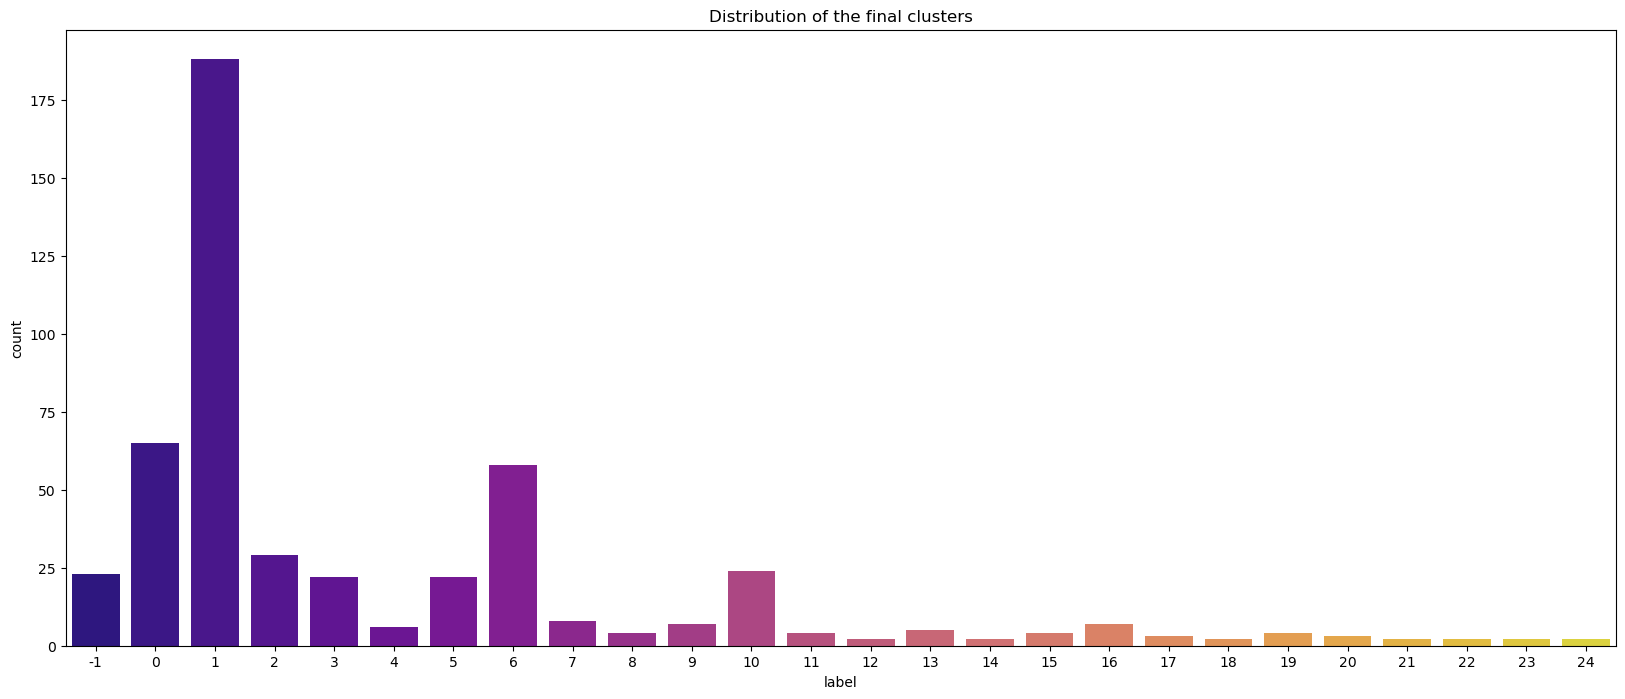

In [31]:
import seaborn as sns

plt.figure(figsize=(20,8))
sns.countplot(data=doc1,x="label", palette="plasma")
plt.title("Distribution of the final clusters")
plt.show()

In [32]:
doc_filter= doc1[doc1['label'] >= 0]

In [33]:
aggregated_descriptions = doc_filter.groupby('label')['desc_ready'].apply(list)

In [34]:
aggregated_descriptions_1 = " ".join(aggregated_descriptions[1])

In [35]:
aggregated_descriptions_1 = aggregated_descriptions_1.replace("  ", "")

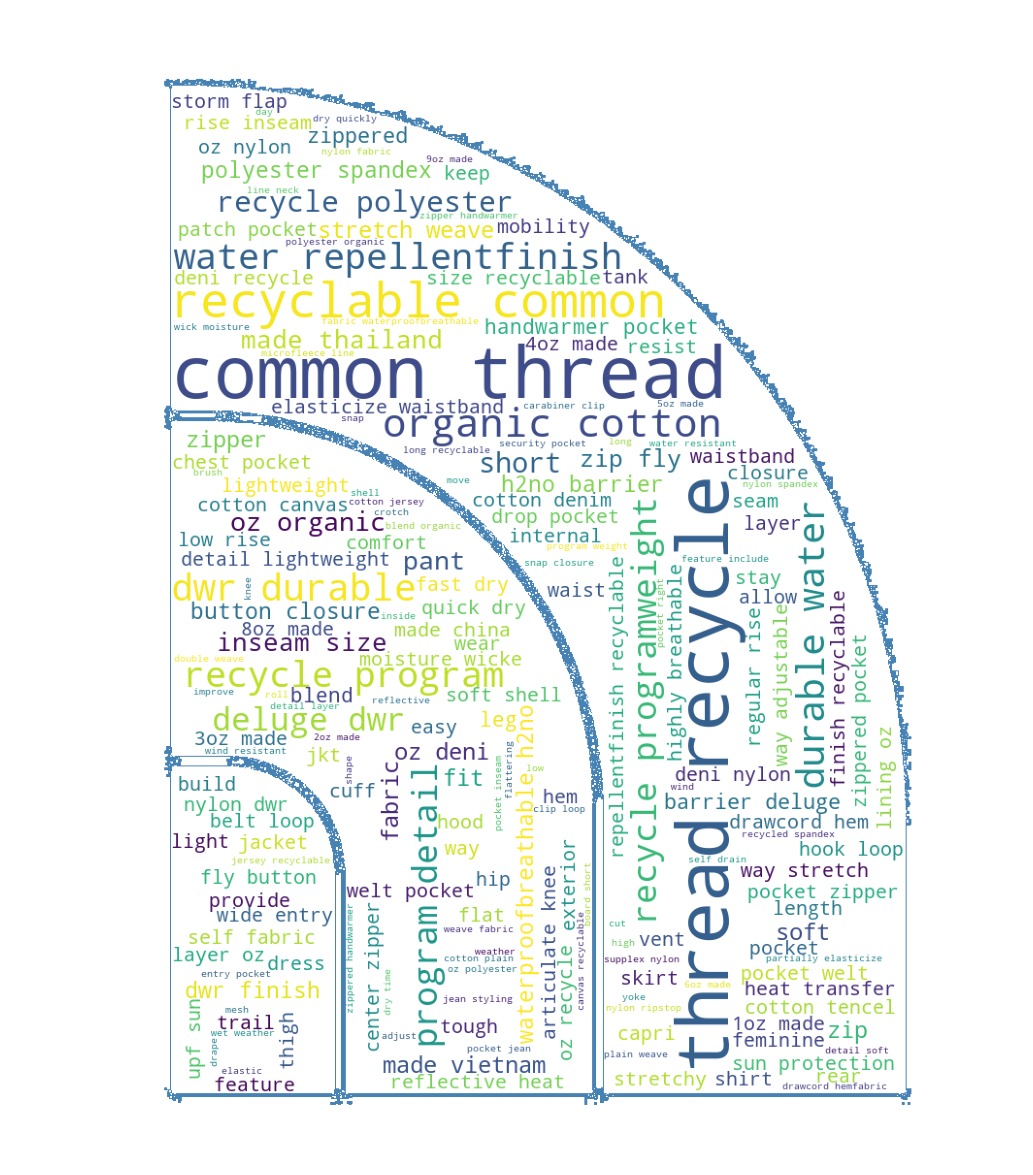

In [37]:
# Import wordcloud and matplotlib et affichage du premier cluster [0]
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import wordcloud

north_face = np.array(Image.open("north-face-logo.jpg"))


# Instanciate wordcloud
wd = wordcloud.WordCloud(background_color="white", contour_width=1, contour_color='steelblue', mask = north_face)

# Generate wordcloud 
cloud = wd.generate(aggregated_descriptions_1)

# Show plot
plt.figure(figsize = (15, 15))
plt.imshow(cloud)
plt.axis("off")
plt.show()

In [38]:
aggregated_descriptions_2 = " ".join(aggregated_descriptions[15])

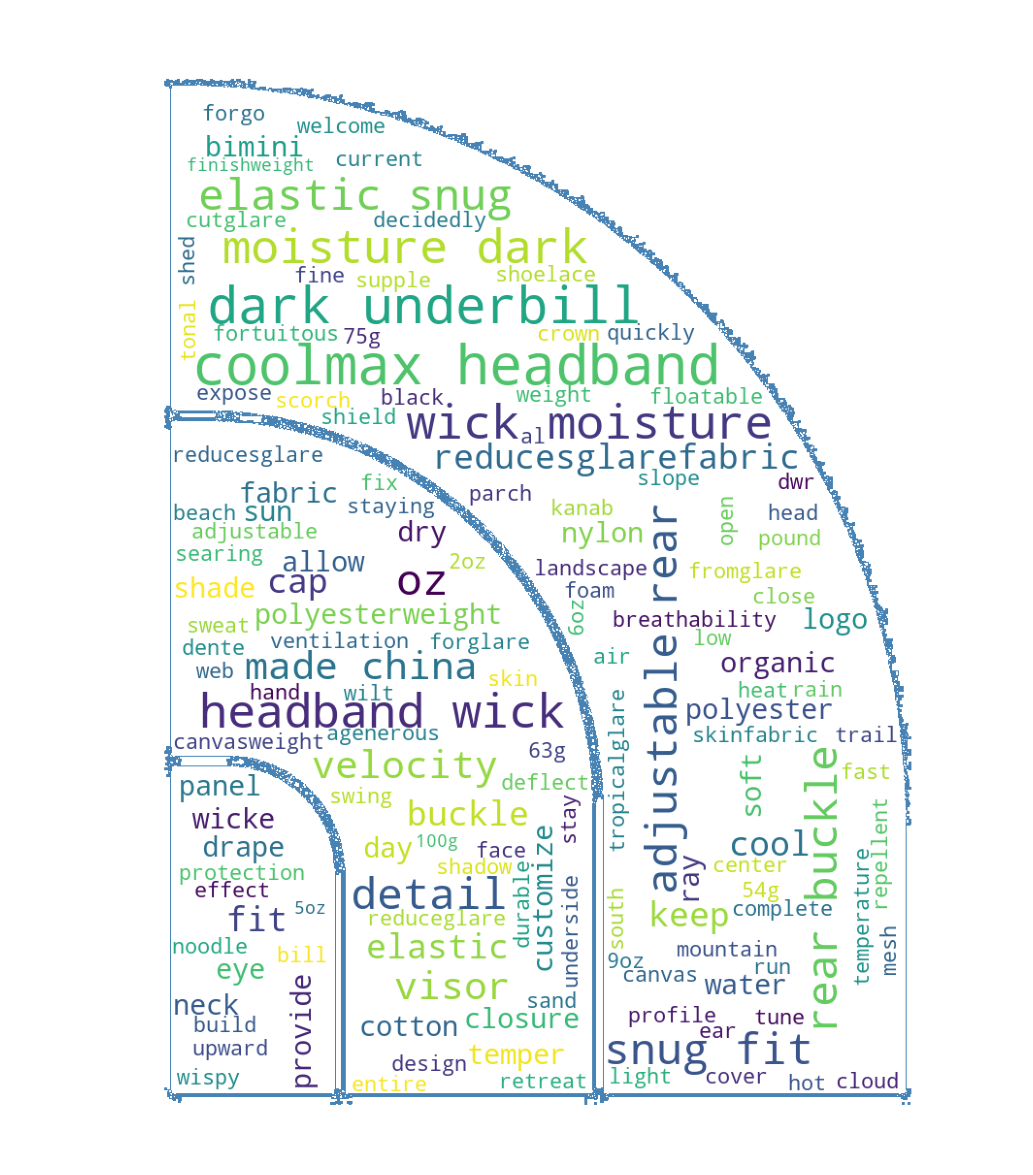

In [39]:
# Import wordcloud and matplotlib et affichage du 2e cluster [15]
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import wordcloud

north_face = np.array(Image.open("north-face-logo.jpg"))


# Instanciate wordcloud
wd = wordcloud.WordCloud(background_color="white", contour_width=1, contour_color='steelblue', mask = north_face)

# Generate wordcloud 
cloud = wd.generate(aggregated_descriptions_2)

# Show plot
plt.figure(figsize = (15, 15))
plt.imshow(cloud)
plt.axis("off")
plt.show()

In [40]:
#déjà nettoyées (stop words supprimés, lemmatisation faite, etc.)
new_corpus = df[['desc_ready']]
# Tfidf transformer 
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    #stop_words='english', 
    smooth_idf=True #évite les divisions / zéro
    )
X = vectorizer.fit_transform(df['desc_ready'])

In [41]:
dense = X.toarray()

In [42]:
# Creating a DataFrame with all the words and tf-idf score (pondération)
tfid_df = pd.DataFrame(dense, 
                        columns=[x for x in vectorizer.get_feature_names_out()])

tfid_df

,000,03oz,0g,0oz,10,100,1000,100g,1021g,1027g,...,zip,zipper,zippered,zippergarage,zipperglue,zippergussete,zippergusseted,zippersfabric,zips,zone
0,0.0,0.0,0.0,0.0,0.000000,0.074967,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.049074,0.212919,0.0,0.0,0.123788,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.050619,0.049161,0.0,0.0,0.0,0.0,...,0.000000,0.112417,0.040646,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.0,0.0,0.0,0.0,0.000000,0.032545,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
496,0.0,0.0,0.0,0.0,0.000000,0.063320,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
497,0.0,0.0,0.0,0.0,0.000000,0.137938,0.0,0.0,0.0,0.0,...,0.139370,0.042056,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
498,0.0,0.0,0.0,0.0,0.000000,0.071566,0.0,0.0,0.0,0.0,...,0.060258,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [43]:
# Transpose dataframe pour permettre l'analyse aisée, chaque colonne est un document
tfid_df = tfid_df.T


# Calculer le max AVANT d'ajouter 'token'
tfid_df['max_tfidf'] = tfid_df.max(axis=1)
# Calculer la moyenne
tfid_df['mean_tfidf'] = tfid_df.mean(axis=1)

# Étape 2 : ajouter la colonne token
tfid_df["token"] = tfid_df.index


tfid_df

,0,1,2,3,4,5,6,7,8,9,...,493,494,495,496,497,498,499,max_tfidf,mean_tfidf,token
000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.134101,0.001186,000
03oz,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.085429,0.000341,03oz
0g,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.237377,0.002142,0g
0oz,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.237377,0.002142,0oz
10,0.0,0.0,0.0,0.000000,0.050619,0.0,0.049137,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.237983,0.013658,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zippergussete,0.0,0.0,0.0,0.123788,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.135861,0.001023,zippergussete
zippergusseted,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111031,0.000443,zippergusseted
zippersfabric,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.137447,0.000549,zippersfabric
zips,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.159570,0.004024,zips


In [44]:
# Trier par importance globale et afficher les 20 meilleurs
top_20 = tfid_df[['token', 'max_tfidf']].sort_values('max_tfidf', ascending=False).head(20)
print(top_20)

                 token  max_tfidf
sonar            sonar   0.611483
barely          barely   0.573972
fleece          fleece   0.565916
coconut        coconut   0.560474
permit          permit   0.556495
skirt            skirt   0.553348
dragoon        dragoon   0.543586
hemp              hemp   0.540770
watertight  watertight   0.538869
peregrine    peregrine   0.535912
sweater        sweater   0.526928
boxer            boxer   0.521224
merino          merino   0.518227
sport            sport   0.512519
future          future   0.507466
pelican        pelican   0.502990
cerro            cerro   0.493342
tank              tank   0.492103
sea                sea   0.486770
trout            trout   0.486693


In [45]:
df[df['desc_ready'].str.contains('sonar', case=False)]

,id,description,desc_clean,desc_tokenized,desc_ready
121,122,Sonar so no t-shirt - Ear-splitting sonar thre...,sonar so no t-shirt ear-splitting sonar threat...,"[sonar, t, -, shirt, ear, -, split, sonar, thr...",sonar t shirt ear split sonar threaten surviva...


In [46]:
# Import plotly express
import plotly.express as px

# Create bar chart
fig = px.bar(top_20, x="token", y="max_tfidf")

# Render chart
fig.show()


In [47]:
import plotly.express as px


fig = px.bar(
    top_20,
    x='token',                         # les mots en abscisse
    y='max_tfidf',                     # le score TF-IDF en ordonnée
    text='max_tfidf',                  # affiche la valeur sur chaque barre
    title='Top 20 des mots les plus significatifs (TF-IDF max)',  
    labels={'token': 'Mot', 'max_tfidf': 'Score TF-IDF max'},    
    color='max_tfidf',                 # couleur selon l'importance
    color_continuous_scale='Blues'     
)


fig.update_layout(
    xaxis_tickangle=-45,               # incliner les mots
    xaxis_title='',                   
    yaxis_title='Score de significativité (TF-IDF)',
    uniformtext_minsize=10,
    uniformtext_mode='hide',
    title_x=0.5,                       # centrer le titre
    height=500                         # taille correcte
)

# Afficher le graphique
fig.show()

In [48]:
# Top 20 par max (mots très marquants)
top_max = tfid_df[['token', 'max_tfidf']].sort_values('max_tfidf', ascending=False).head(20)

# Top 20 par mean (mots globalement présents)
top_mean = tfid_df[['token', 'mean_tfidf']].sort_values('mean_tfidf', ascending=False).head(20)

In [49]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Top 20 - Max TF-IDF", "Top 20 - Mean TF-IDF"),
    shared_yaxes=False
)

fig.add_trace(
    go.Bar(x=top_max['token'], y=top_max['max_tfidf'], name="Max"),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=top_mean['token'], y=top_mean['mean_tfidf'], name="Mean", marker_color='lightblue'),
    row=1, col=2
)

fig.update_layout(title="Comparaison : mots marquants vs mots fréquents", showlegend=False)
fig.show()

In [50]:
tfid_df

,0,1,2,3,4,5,6,7,8,9,...,493,494,495,496,497,498,499,max_tfidf,mean_tfidf,token
000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.134101,0.001186,000
03oz,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.085429,0.000341,03oz
0g,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.237377,0.002142,0g
0oz,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.237377,0.002142,0oz
10,0.0,0.0,0.0,0.000000,0.050619,0.0,0.049137,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.237983,0.013658,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zippergussete,0.0,0.0,0.0,0.123788,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.135861,0.001023,zippergussete
zippergusseted,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111031,0.000443,zippergusseted
zippersfabric,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.137447,0.000549,zippersfabric
zips,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.159570,0.004024,zips


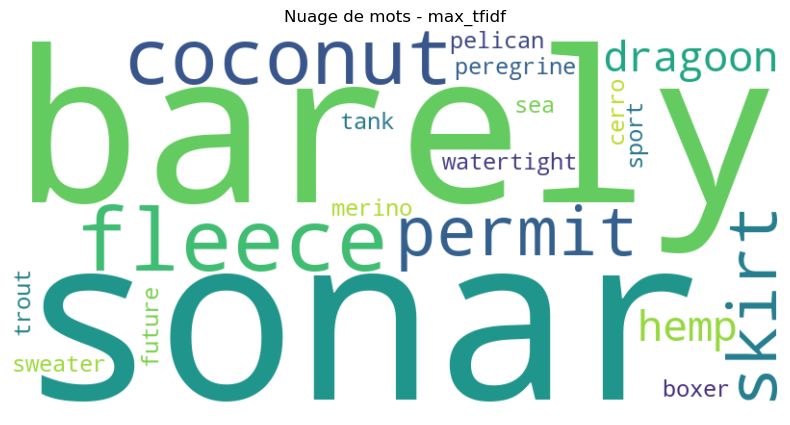

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Nuage de mots pour max_tfidf
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(zip(top_max['token'], top_max['max_tfidf'])))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nuage de mots - max_tfidf")
plt.show()

In [52]:
doc1

,desc_ready,label
0,active classic boxer reason boxer cult favorit...,0
1,active sport boxer brief skin upglory require ...,0
2,active sport brief superbreathable fly brief m...,0
3,alpineguide pant skin climb ice switch rock tr...,1
4,alpine wind jkt high ridge steep ice alpine ja...,1
...,...,...
495,cap 2 bottom cut loose madden crowd search und...,0
496,cap 2 crew crew take edge fickle weather clear...,0
497,time shell need use morning time umbrella time...,1
498,wear cargo short wear cargo short bask theglor...,1


In [53]:
df_words=doc1.copy()

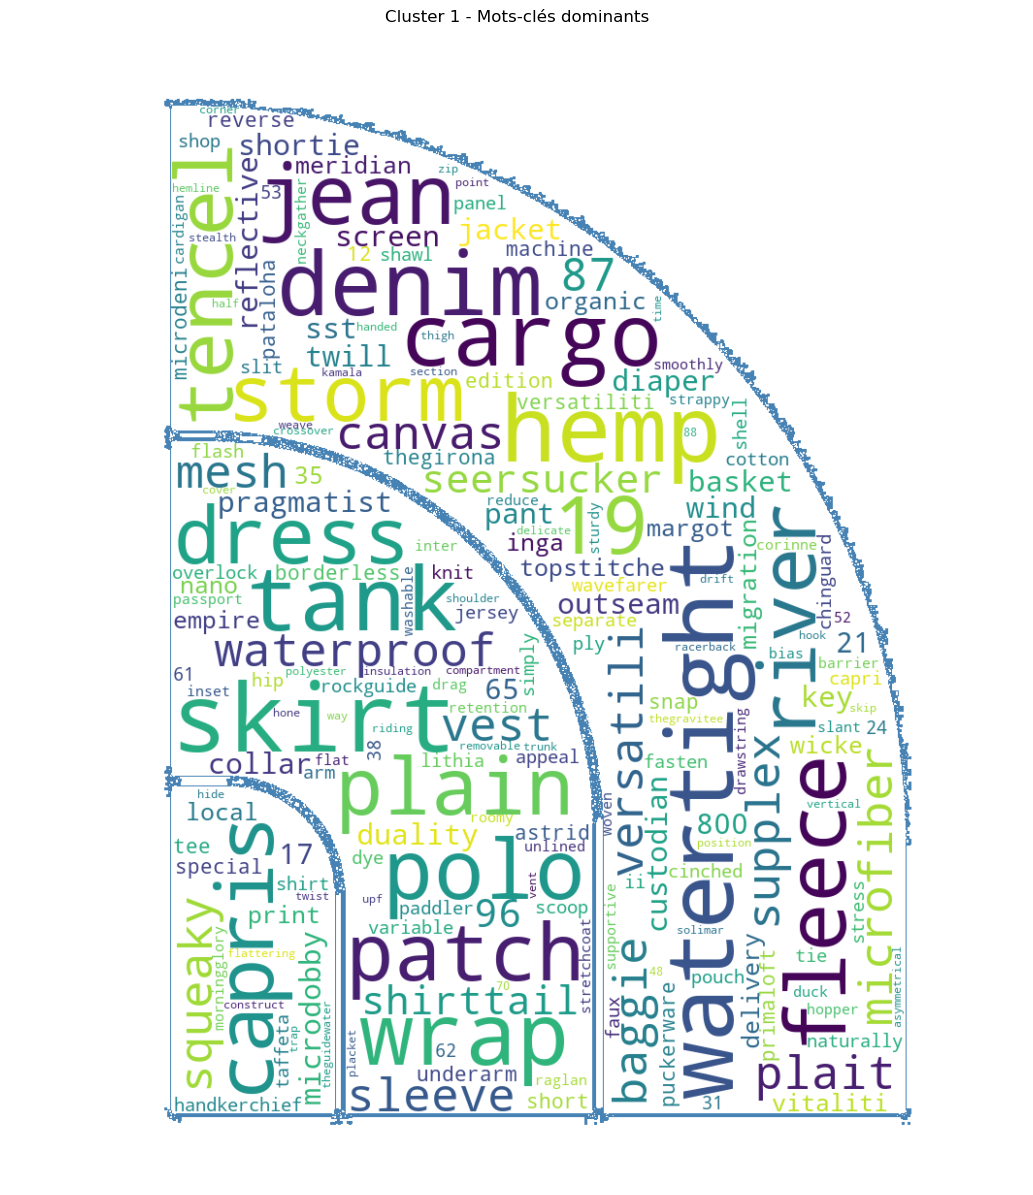

In [54]:
# Exemple : Cluster 1
cluster_1_products = df_words[df_words['label'] == 1]
# Pour le cluster 1
desc_cluster_1 = cluster_1_products['desc_ready']
# Vectoriser les descriptions du cluster 1
vectorizer = TfidfVectorizer(stop_words='english', smooth_idf=True)
tfidf_matrix_cluster_1 = vectorizer.fit_transform(desc_cluster_1)
# Convertir en DataFrame
tfidf_df_cluster_1 = pd.DataFrame(tfidf_matrix_cluster_1.toarray(), 
                                columns=vectorizer.get_feature_names_out())
# Transposer
tfidf_df_cluster_1 = tfidf_df_cluster_1.T

# Calculer max_tfidf pour le cluster 1
tfidf_df_cluster_1['max_tfidf'] = tfidf_df_cluster_1.max(axis=1)
tfidf_df_cluster_1['token'] = tfidf_df_cluster_1.index
# Tri par max_tfidf décroissant
top_words_cluster_1 = tfidf_df_cluster_1[['token', 'max_tfidf']].sort_values('max_tfidf', ascending=False)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(top_words, title):
    # Instanciate wordcloud
    north_face = np.array(Image.open("north-face-logo.jpg"))
    #wd = wordcloud.WordCloud(background_color="white", contour_width=1, contour_color='steelblue', mask = north_face)   
    wordcloud = WordCloud(background_color='white', contour_width=1, contour_color='steelblue', mask = north_face).generate_from_frequencies(dict(zip(top_words['token'], top_words['max_tfidf'])))
    plt.figure(figsize=(15, 15))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Nuage de mots pour le cluster 1
plot_wordcloud(top_words_cluster_1, "Cluster 1 - Mots-clés dominants")

In [55]:
top_words_cluster_1 = tfidf_df_cluster_1[['token', 'max_tfidf']].sort_values('max_tfidf', ascending=False).head(20)
top_words_cluster_1

,token,max_tfidf
skirt,skirt,0.541153
watertight,watertight,0.523027
hemp,hemp,0.509629
tank,tank,0.466653
denim,denim,0.463286
cargo,cargo,0.458032
wrap,wrap,0.455873
polo,polo,0.417107
fleece,fleece,0.410021
jean,jean,0.409246


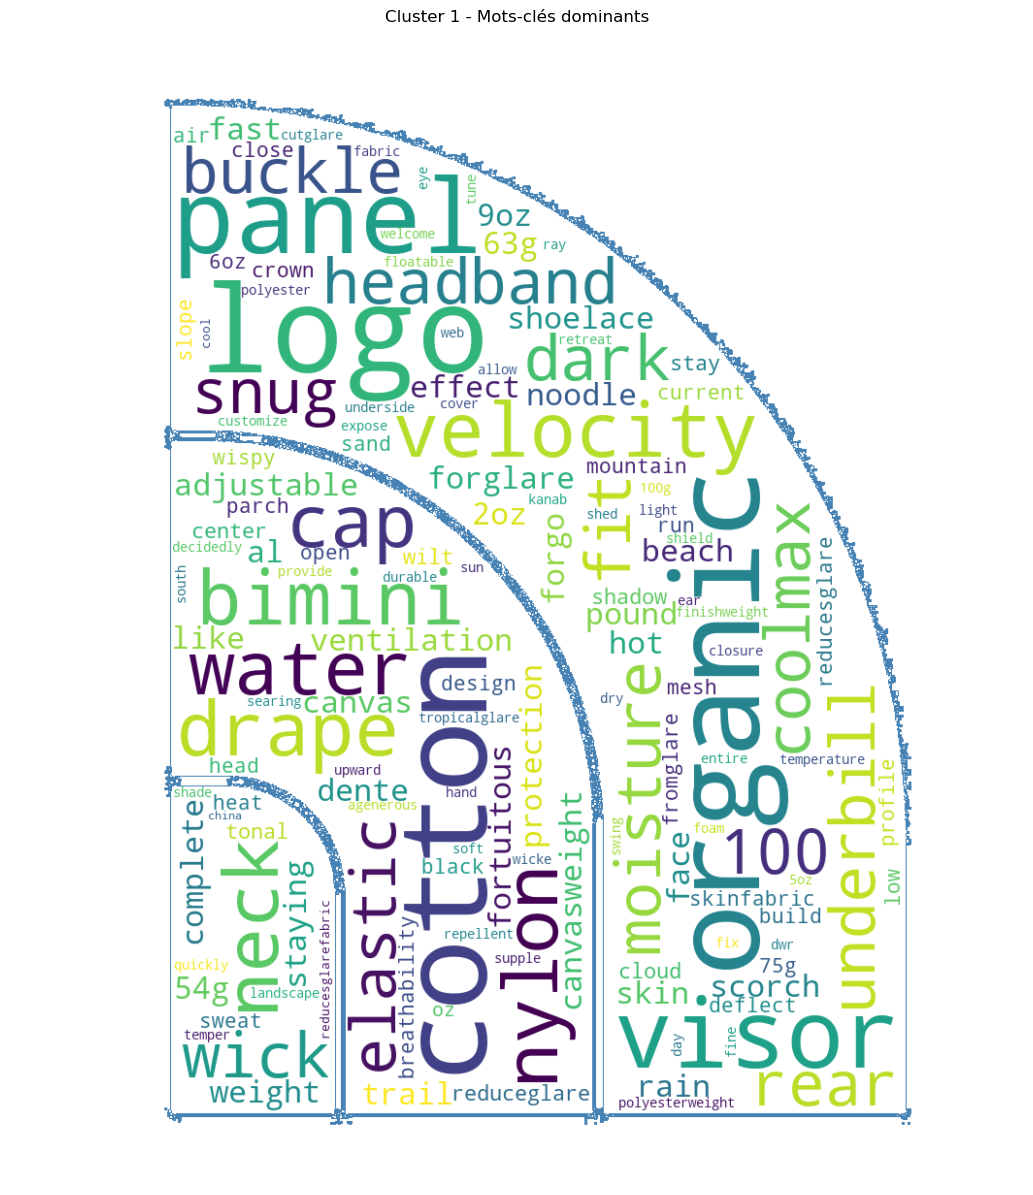

In [56]:
# Exemple : Cluster 1
cluster_1_products = df_words[df_words['label'] == 15]
# Pour le cluster 1
desc_cluster_1 = cluster_1_products['desc_ready']
# Vectoriser les descriptions du cluster 1
vectorizer = TfidfVectorizer(stop_words='english', smooth_idf=True)
tfidf_matrix_cluster_1 = vectorizer.fit_transform(desc_cluster_1)
# Convertir en DataFrame
tfidf_df_cluster_1 = pd.DataFrame(tfidf_matrix_cluster_1.toarray(), 
                                columns=vectorizer.get_feature_names_out())
# Transposer
tfidf_df_cluster_1 = tfidf_df_cluster_1.T

# Calculer max_tfidf pour le cluster 1
tfidf_df_cluster_1['max_tfidf'] = tfidf_df_cluster_1.max(axis=1)
tfidf_df_cluster_1['token'] = tfidf_df_cluster_1.index
# Tri par max_tfidf décroissant
top_words_cluster_1 = tfidf_df_cluster_1[['token', 'max_tfidf']].sort_values('max_tfidf', ascending=False)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(top_words, title):
    wordcloud = WordCloud(background_color='white', contour_width=1, contour_color='steelblue', mask = north_face).generate_from_frequencies(dict(zip(top_words['token'], top_words['max_tfidf'])))
    plt.figure(figsize=(15, 15))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Nuage de mots pour le cluster 1
plot_wordcloud(top_words_cluster_1, "Cluster 1 - Mots-clés dominants")

In [57]:
top_words_cluster_1 = tfidf_df_cluster_1[['token', 'max_tfidf']].sort_values('max_tfidf', ascending=False).head(20)
top_words_cluster_1

,token,max_tfidf
logo,logo,0.289063
organic,organic,0.289063
cotton,cotton,0.289063
panel,panel,0.274162
visor,visor,0.234815
velocity,velocity,0.234815
bimini,bimini,0.231158
drape,drape,0.231158
neck,neck,0.231158
water,water,0.231158


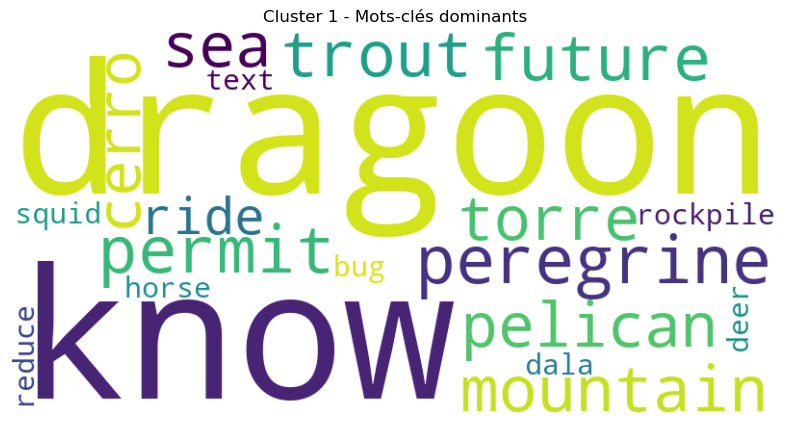

In [58]:
# Exemple : Cluster 1
cluster_1_products = df_words[df_words['label'] == 6]
# Pour le cluster 1
desc_cluster_1 = cluster_1_products['desc_ready']
# Vectoriser les descriptions du cluster 1
vectorizer = TfidfVectorizer(stop_words='english', smooth_idf=True)
tfidf_matrix_cluster_1 = vectorizer.fit_transform(desc_cluster_1)
# Convertir en DataFrame
tfidf_df_cluster_1 = pd.DataFrame(tfidf_matrix_cluster_1.toarray(), 
                                columns=vectorizer.get_feature_names_out())
# Transposer
tfidf_df_cluster_1 = tfidf_df_cluster_1.T

# Calculer max_tfidf pour le cluster 1
tfidf_df_cluster_1['max_tfidf'] = tfidf_df_cluster_1.max(axis=1)
tfidf_df_cluster_1['token'] = tfidf_df_cluster_1.index
# Tri par max_tfidf décroissant
top_words_cluster_1 = tfidf_df_cluster_1[['token', 'max_tfidf']].sort_values('max_tfidf', ascending=False).head(20)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(top_words, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(zip(top_words['token'], top_words['max_tfidf'])))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Nuage de mots pour le cluster 1
plot_wordcloud(top_words_cluster_1, "Cluster 1 - Mots-clés dominants")

In [59]:
top_words_cluster_1 = tfidf_df_cluster_1[['token', 'max_tfidf']].sort_values('max_tfidf', ascending=False).head(20)
top_words_cluster_1

,token,max_tfidf
dragoon,dragoon,0.602469
know,know,0.599298
peregrine,peregrine,0.591120
permit,permit,0.577111
trout,trout,0.548026
mountain,mountain,0.542966
future,future,0.542624
pelican,pelican,0.542079
sea,sea,0.541685
cerro,cerro,0.519485


In [60]:
tfidf_df_cluster_1

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,max_tfidf,token
000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.152684,000
0g,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.182729,0g
0oz,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.182729,0oz
100,0.090759,0.091608,0.091538,0.105081,0.077177,0.077689,0.077200,0.078521,0.088496,0.075384,...,0.039495,0.098001,0.103752,0.092350,0.043083,0.088859,0.059293,0.095933,0.119227,100
103g,0.000000,0.000000,0.000000,0.000000,0.267656,0.269433,0.267738,0.272319,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.272319,103g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wroblewski,0.000000,0.000000,0.000000,0.182215,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.182215,wroblewski
www,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.144821,www
yarn,0.050246,0.101433,0.101355,0.058175,0.000000,0.000000,0.000000,0.000000,0.097987,0.041734,...,0.043731,0.108511,0.057439,0.051127,0.047704,0.049194,0.131304,0.106221,0.131304,yarn
yosemite,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.402140,yosemite


In [61]:
simu_df = df[['id','description']].copy()

In [62]:
simu_df['label'] = dbscan.labels_


In [63]:
simu_df


,id,description,label
0,1,Active classic boxers - There's a reason why o...,0
1,2,Active sport boxer briefs - Skinning up Glory ...,0
2,3,Active sport briefs - These superbreathable no...,0
3,4,"Alpine guide pants - Skin in, climb ice, switc...",1
4,5,"Alpine wind jkt - On high ridges, steep ice an...",1
...,...,...,...
495,496,Cap 2 bottoms - Cut loose from the maddening c...,0
496,497,Cap 2 crew - This crew takes the edge off fick...,0
497,498,All-time shell - No need to use that morning T...,1
498,499,All-wear cargo shorts - All-Wear Cargo Shorts ...,1


# Simple moteur de recommandation

In [112]:
# Créer une copie avec id, description et label
simu_df = df[['id', 'description']].copy()
simu_df['label'] = dbscan.labels_

# Demander à l'utilisateur un ID
try:
    choice = int(input("Choisissez un ID entre 0 et 499 : "))
except ValueError:
    print("Veuillez entrer un nombre entier.")
    exit()

# Vérifier que l'ID existe
if choice not in simu_df['id'].values:
    print(f"L'ID {choice} n'existe pas dans le catalogue.")
else:
    # Récupérer le label du produit
    label = simu_df.loc[simu_df['id'] == choice, 'label'].values[0]
    print(f"Le label pour l'ID {choice} est {label}.")

    # Filtrer les produits du même cluster
    same_cluster = simu_df[simu_df['label'] == label]

    # Exclure le produit lui-même (optionnel : éviter de se recommander soi-même)
    same_cluster = same_cluster[same_cluster['id'] != choice]

    # Nombre de produits disponibles
    n_available = len(same_cluster)

    # Déterminer combien d'articles on peut suggérer
    n_to_suggest = min(5, n_available)

    if n_to_suggest == 0:
        print("Aucun autre produit similaire trouvé dans ce cluster.")
    else:
        # Ajuster le nombre d'échantillons
        suggestions = same_cluster.sample(n_to_suggest)
        print(f"Voici {n_to_suggest} article(s) similaire(s) à l'ID {choice} :")
        print(suggestions[['id', 'description']])

Le label pour l'ID 255 est 3.
Voici 5 article(s) similaire(s) à l'ID 255 :
      id                                        description
257  258  Sport top - The loose, performance fit of the ...
220  221  Solid bibiana 1 piece - The sporty Bibiana One...
219  220  Solid betina btm - Our fullest coverage bottom...
7      8  Print banded betina btm - Our fullest coverage...
253  254  Solid paries btm - The boy-short-style Paries ...


# Topic Modeling


In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy

# TruncatedSVD from sklearn
from sklearn.decomposition import TruncatedSVD

In [91]:
svd_model = TruncatedSVD(n_components=19, n_iter=100, random_state=122)
lsa = svd_model.fit_transform(X)

In [92]:
topic_encoded_df = pd.DataFrame(lsa, columns = ["topic_{}".format(i+1) for i in range(19)], index = df.index)
topic_encoded_df["text"] = df['desc_ready'].values
topic_encoded_df

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19,text
0,0.269334,-0.052115,0.188441,0.077587,-0.126032,-0.000442,-0.039954,-0.027882,-0.155181,-0.030506,0.017291,-0.054144,-0.031007,0.033757,0.025625,-0.019270,-0.057624,0.037730,0.040729,active classic boxer reason boxer cult favorit...
1,0.268035,-0.069178,0.101221,0.092805,-0.020273,0.084194,-0.048604,-0.019362,-0.109487,0.046076,-0.005426,-0.182320,-0.002791,0.068705,-0.058000,0.036133,0.065490,0.104760,0.061806,active sport boxer brief skin upglory require ...
2,0.255211,-0.092521,0.102548,0.025111,-0.027444,0.089129,-0.002769,0.051107,-0.038312,0.019748,-0.009102,-0.212177,0.041086,0.081288,-0.054459,0.001489,0.068489,0.068094,0.074061,active sport brief superbreathable fly brief m...
3,0.374912,-0.246397,-0.115618,-0.126347,0.046167,-0.019475,-0.003801,-0.038846,-0.082528,0.123741,0.006984,-0.062384,-0.162403,-0.045120,0.046300,0.022221,-0.018976,-0.045034,0.201947,alpineguide pant skin climb ice switch rock tr...
4,0.399452,-0.264755,-0.036292,-0.228289,-0.028985,-0.053859,0.035456,0.079081,-0.034346,0.193807,0.032349,0.020787,-0.217370,0.278639,0.051683,-0.052400,-0.028064,-0.015241,-0.006837,alpine wind jkt high ridge steep ice alpine ja...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.312408,-0.070397,0.390471,0.045966,-0.252298,-0.036696,0.013884,-0.072402,-0.330971,-0.108896,0.005834,-0.024679,-0.055755,0.005225,-0.028847,0.006817,-0.064166,-0.043835,0.053446,cap 2 bottom cut loose madden crowd search und...
496,0.359614,-0.072957,0.481281,-0.027145,-0.308001,-0.059878,0.034296,0.008712,-0.259510,-0.173150,-0.011042,0.062510,-0.114888,0.077777,-0.073622,0.107344,-0.019367,0.000730,-0.020137,cap 2 crew crew take edge fickle weather clear...
497,0.337991,-0.207848,-0.066699,-0.231694,-0.012386,-0.142335,0.159014,-0.118710,0.050841,0.004322,0.027331,0.110905,0.082365,-0.029647,-0.016876,-0.017824,-0.034444,0.002523,0.016401,time shell need use morning time umbrella time...
498,0.306922,0.057140,-0.129345,0.322250,0.040402,-0.125489,-0.103084,-0.018715,-0.075954,-0.050718,-0.001639,0.114766,0.088106,0.093567,-0.085494,-0.046403,0.095578,-0.127432,-0.197249,wear cargo short wear cargo short bask theglor...


In [74]:
svd_model.components_

array([[ 0.00266504,  0.00059162,  0.00594908, ...,  0.00086215,
         0.01437356,  0.00769913],
       [ 0.00029427, -0.00074638,  0.00394682, ..., -0.00127051,
        -0.01991743, -0.01149986],
       [-0.00145139, -0.00072546, -0.00525887, ..., -0.00091916,
        -0.01524323, -0.00253335],
       ...,
       [ 0.00349796,  0.00046157, -0.02559073, ...,  0.00045872,
         0.01590505, -0.03468018],
       [-0.00356838, -0.00036427,  0.0263526 , ...,  0.00176102,
         0.02340595, -0.05036255],
       [ 0.01600219, -0.00097051,  0.02748849, ...,  0.00141442,
        -0.0103058 , -0.00633113]], shape=(19, 4328))

In [93]:
X = vectorizer.fit_transform(df['desc_ready'])
vectorizer.get_feature_names_out()

array(['000', '03oz', '0g', ..., 'zippersfabric', 'zips', 'zone'],
      shape=(4276,), dtype=object)

In [94]:
topic = pd.DataFrame(svd_model.components_, index = ["topic_{}".format(i+1) for i in range(19)])
topic.columns= vectorizer.get_feature_names_out()
topic_t = topic.transpose()
topic_t

,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19
000,0.002749,0.000156,-0.001578,-0.004359,0.002321,0.002035,0.000962,0.003721,-0.002214,0.004728,0.001014,-0.000964,-0.000445,0.008661,-0.007274,-0.004420,0.000284,-0.003301,0.015847
03oz,0.000595,-0.000742,-0.000728,-0.001395,0.000391,-0.000985,0.001346,-0.001874,0.000865,-0.001791,-0.000204,0.001523,0.001225,-0.001150,-0.000913,-0.000592,0.000090,-0.000333,-0.000973
0g,0.005948,0.003930,-0.005103,0.011962,-0.001287,-0.012887,0.002694,0.005706,0.003260,-0.013028,0.002290,0.011343,0.003495,0.015759,0.008402,0.010360,-0.018865,0.030991,0.025809
0oz,0.005948,0.003930,-0.005103,0.011962,-0.001287,-0.012887,0.002694,0.005706,0.003260,-0.013028,0.002290,0.011343,0.003495,0.015759,0.008402,0.010360,-0.018865,0.030991,0.025809
10,0.049759,-0.005762,-0.042008,0.089171,0.011454,-0.045789,0.023881,0.004780,0.004057,-0.028117,0.009441,0.000506,0.013463,0.034002,0.017382,0.040796,-0.033800,0.059688,0.075018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zippergussete,0.003485,-0.004191,-0.003315,-0.002809,0.002125,-0.000728,-0.001142,-0.002743,-0.005926,0.009159,0.000576,-0.004627,-0.012485,-0.002929,0.004937,0.001052,-0.001208,-0.003833,0.015746
zippergusseted,0.000689,-0.000986,-0.000970,-0.000626,0.000599,0.000291,0.000352,-0.000441,-0.001046,0.000683,0.000164,-0.000541,-0.000258,0.000738,0.000510,0.000185,0.000057,-0.000967,0.002805
zippersfabric,0.000868,-0.001262,-0.000924,-0.002120,0.000497,0.000286,-0.003294,0.006756,-0.000352,-0.003138,-0.000891,0.000125,-0.001039,-0.000750,0.001122,0.000076,0.000860,0.001605,0.001433
zips,0.014527,-0.019771,-0.015235,-0.028451,0.005174,-0.011790,0.026945,-0.048689,0.016223,-0.022854,-0.001715,0.029598,0.001394,-0.028760,-0.057234,-0.002892,0.019014,0.019798,-0.013193


In [95]:
# Associer chaque mot au topic où il a le poids le plus fort (en valeur absolue)
dominant_topic = topic_t.abs().idxmax(axis=1)

# Ajouter les poids réels pour référence
max_weight = topic_t.max(axis=1)

# Fusionner dans un DataFrame
df_dominant = pd.DataFrame({
    "mot": topic_t.index,
    "topic_dominant": dominant_topic,
    "poids_max": max_weight
}).sort_values(by="topic_dominant")


In [96]:
df_dominant

,mot,topic_dominant,poids_max
lightweight,lightweight,topic_1,0.068641
common,common,topic_1,0.161417
durable,durable,topic_1,0.101344
fabric,fabric,topic_1,0.128145
feature,feature,topic_1,0.049591
...,...,...,...
ventilation,ventilation,topic_9,0.029158
castle,castle,topic_9,0.008484
cavern,cavern,topic_9,0.002309
cast,cast,topic_9,0.007279


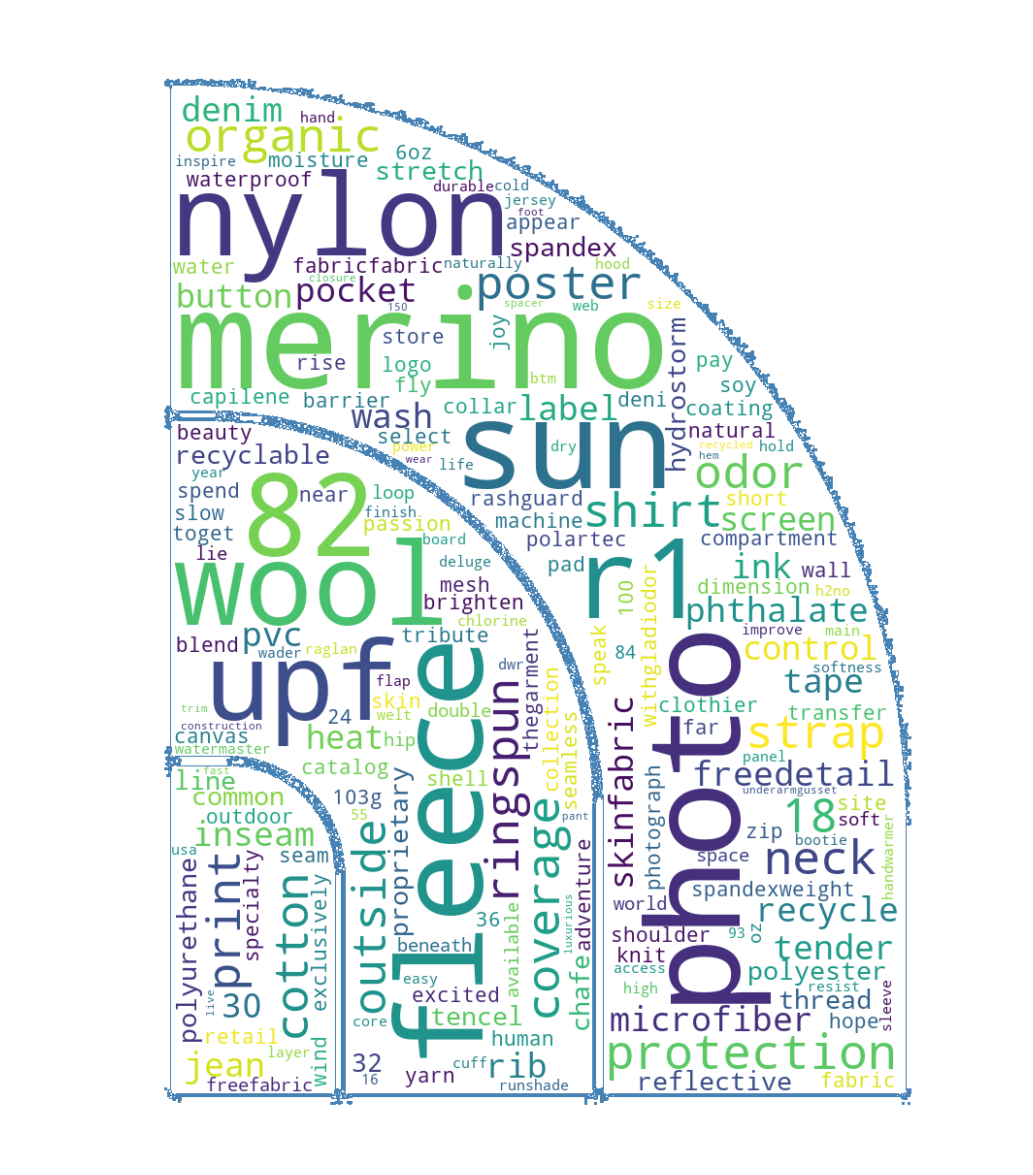

In [97]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import wordcloud

# Masque en forme de logo
north_face = np.array(Image.open("north-face-logo.jpg"))

# Word frequencies : mot -> poids
word_freq = dict(zip(df_dominant["mot"], df_dominant["poids_max"]))

# Instanciate wordcloud
wd = wordcloud.WordCloud(
    background_color="white",
    contour_width=1,
    contour_color='steelblue',
    mask=north_face
)

# Générer le wordcloud
cloud = wd.generate_from_frequencies(word_freq)

# Afficher
plt.figure(figsize=(15, 15))
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [85]:
df_dominant.head(20)


,mot,topic_dominant,poids_max
lightweight,lightweight,topic_1,0.068641
common,common,topic_1,0.161417
durable,durable,topic_1,0.101344
fabric,fabric,topic_1,0.128145
feature,feature,topic_1,0.049591
pocket,pocket,topic_1,0.194507
oz,oz,topic_1,0.111263
recycle,recycle,topic_1,0.208801
recyclable,recyclable,topic_1,0.165176
soft,soft,topic_1,0.109162


In [ ]:

import plotly.express as px

# 🔧 Paramètre : choisis le topic à afficher
topic_to_plot = "topic_16"  # ici topic 16

# Filtrer les mots du topic + trier par poids décroissant : 20 meilleurs
top_words = (df_dominant[df_dominant['topic_dominant'] == topic_to_plot]
             .sort_values(by='poids_max', ascending=False)
             .head(20)) 

# Graphique avec le style TF-IDF
fig = px.bar(
    top_words,
    x='mot',                               
    y='poids_max',                          
    text='poids_max',                       
    title=f'Top 20 des mots les plus significatifs - {topic_to_plot}',  
    labels={'mot': 'Mot', 'poids_max': 'Score de significativité (poids max)'},  
    color='poids_max',                     
    color_continuous_scale='Blues'          
)

# Mise en page identique à ton TF-IDF
fig.update_layout(
    xaxis_tickangle=-45,                     # mots inclinés
    xaxis_title='',                          
    yaxis_title='Score de significativité (poids max)',
    uniformtext_minsize=10,
    uniformtext_mode='hide',
    title_x=0.5,                            
    height=500,
    coloraxis_showscale=False               
)

fig.update_traces(texttemplate='%{text:.4f}')


fig.show()

In [ ]:

import plotly.express as px

# 🔧 Paramètre : choisis le topic à afficher
topic_to_plot = "topic_2" 

# Filtrer les mots du topic + trier par poids décroissant
top_words = (df_dominant
             .sort_values(by='poids_max', ascending=False)
             .head(20)
            )

# Créer le graphique avec le style TF-IDF
fig = px.bar(
    top_words,
    x='mot',                                
    y='poids_max',                          
    text='poids_max',                      
    title=f'Top 20 des mots les plus significatifs - {topic_to_plot}',  
    labels={'mot': 'Mot', 'poids_max': 'Score de significativité (poids max)'},  
    color='poids_max',                     
    color_continuous_scale='Blues'         
)

# Mise en page identique à ton TF-IDF
fig.update_layout(
    xaxis_tickangle=-45,                    
    xaxis_title='',                          
    yaxis_title='Score de significativité (poids max)',
    uniformtext_minsize=10,
    uniformtext_mode='hide',
    title_x=0.5,                            
    height=500,
    coloraxis_showscale=False                
)

fig.update_traces(texttemplate='%{text:.4f}')

fig.show()